# Sheet 2 – Moments and Their Estimation
## 2.1 Bias and Variance in the Exponential Distribution

---

a.

**Mean:**

$$\mu = \mathbb{E}[X] = \int_0^\infty x  \lambda e^{-\lambda x}\,dx$$

Integrating by parts with $u = x$, $dv = \lambda e^{-\lambda x}dx$:

$$= \left[-x e^{-\lambda x}\right]_0^\infty + \int_0^\infty e^{-\lambda x}\,dx = 0 + \left[-\frac{1}{\lambda}e^{-\lambda x}\right]_0^\infty = \frac{1}{\lambda}$$

$${\mu = \frac{1}{\lambda}}$$

**Variance:**

First compute $\mathbb{E}[X^2]$ via integration by parts twice:

$$\mathbb{E}[X^2] = \int_0^\infty x^2 \lambda e^{-\lambda x}\,dx = \frac{2}{\lambda^2}$$

Then:

$$\sigma^2 = \mathbb{E}[X^2] - \mu^2 = \frac{2}{\lambda^2} - \frac{1}{\lambda^2}$$

$${\sigma^2 = \frac{1}{\lambda^2}}$$


b. 

**Unbiasedness:**

$$\mathbb{E}[\hat{\mu}] = \mathbb{E}\!\left[\frac{1}{n}\sum_{i=1}^n X_i\right] = \frac{1}{n}\sum_{i=1}^n \mathbb{E}[X_i] = \frac{1}{n} n  \frac{1}{\lambda} = \frac{1}{\lambda} = \mu$$

**Variance:**

Since the $X_i$ are iid:

$$\sigma^2_{\hat{\mu}} = \text{Var}\!\left(\frac{1}{n}\sum_{i=1}^n X_i\right) = \frac{1}{n^2}\sum_{i=1}^n \text{Var}(X_i) = \frac{1}{n^2} n \frac{1}{\lambda^2}$$

$${\sigma^2_{\hat{\mu}} = \frac{1}{n\lambda^2}}$$

The variance shrinks as $1/n$, consistent with the central limit theorem.


c.

$\hat{\lambda}$ is a nonlinear function of $\hat{\mu}$, so we cannot simply pass the expectation through. By Jensen's inequality, since $g(x) = 1/x$ is strictly convex for $x > 0$:

$$\mathbb{E}\!\left[\frac{1}{\hat{\mu}}\right] > \frac{1}{\mathbb{E}[\hat{\mu}]} = \frac{1}{\mu} = \lambda$$

Therefore $\hat{\lambda}$ is positively biased: it systematically overestimates $\lambda$.


d. 
The MSE is:

$$\text{MSE}(\hat{\mu}) = \text{Var}(\hat{\mu}) + \left[\text{Bias}(\hat{\mu})\right]^2$$

Since $\hat{\mu}$ is unbiased, $\text{Bias}(\hat{\mu}) = 0$, and the MSE reduces to the variance:

$$\text{MSE}(\hat{\mu}) = \text{Var}(\hat{\mu}) + 0 = \frac{1}{n\lambda^2}$$

$${\text{MSE}(\hat{\mu}) = \frac{\sigma^2}{n} = \frac{1}{n\lambda^2}}$$

**Physical interpretation:** The MSE measures the expected squared deviation of our estimate from the true mean $\mu = 1/\lambda$. For example in radioactive decay, $\mu$ has units of time; the MSE has units of time$^2$, and its square root (the standard error $1/(\lambda\sqrt{n})$) gives the typical magnitude of the error in those same time units.

# 2.2 The central limit theorem

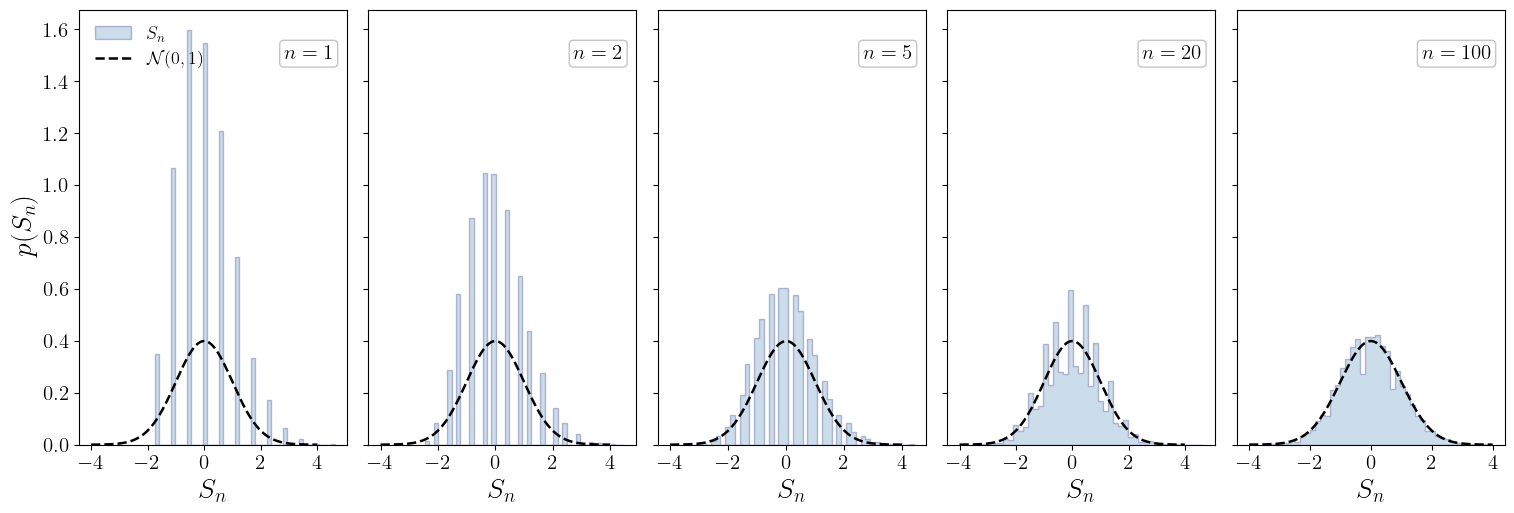

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from matplotlib.ticker import MaxNLocator
from scipy.stats import norm

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

rng = np.random.default_rng(seed=42)
mu_pois = 3
N_samples = 10_000
n_values = [1, 2, 5, 20, 100]
x_plot = np.linspace(-4, 4, 300)

# --- Part (a) and (b): histograms + Gaussian overlay ---
fig, axes = plt.subplots(1, len(n_values), figsize=(15.5, 5.8), sharey=True)

for ax, n in zip(axes, n_values):
    # Draw N_samples independent realisations of n Poisson variables X_i ~ Pois(mu).
    draws = rng.poisson(lam=mu_pois, size=(N_samples, n))

    # Standardised CLT sum: S_n = (sum_i X_i - n*mu)/sqrt(n*mu).
    # If CLT applies, this should approach N(0,1) as n increases.
    S_n = (draws.sum(axis=1) - n * mu_pois) / np.sqrt(n * mu_pois)

    ax.hist(
        S_n,
        bins=45,
        density=True,
        histtype='stepfilled',
        facecolor='steelblue',
        edgecolor='midnightblue',
        linewidth=1.0,
        alpha=0.28,
        label=r'$S_n$'
    )
    # Reference Gaussian for visual convergence check.
    ax.plot(x_plot, norm.pdf(x_plot), 'k--', lw=1.8, label=r'$\mathcal{N}(0,1)$')
    ax.text(
        0.95, 0.92, rf'$n={n}$',
        transform=ax.transAxes,
        ha='right', va='top', fontsize=fontsi,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.75', alpha=0.9)
    )
    ax.set_xlabel(r'$S_n$', fontsize=fontsi2)
    ax.tick_params(labelsize=fontsi)
    ax.xaxis.set_major_locator(MaxNLocator(5))

axes[0].set_ylabel(r'$p(S_n)$', fontsize=fontsi2)
axes[0].legend(fontsize=fontsi - 2, frameon=False, loc='upper left')
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.2, top=0.95, wspace=0.08)
plt.savefig('./sheet2_output/clt_poisson.pdf')
plt.show()



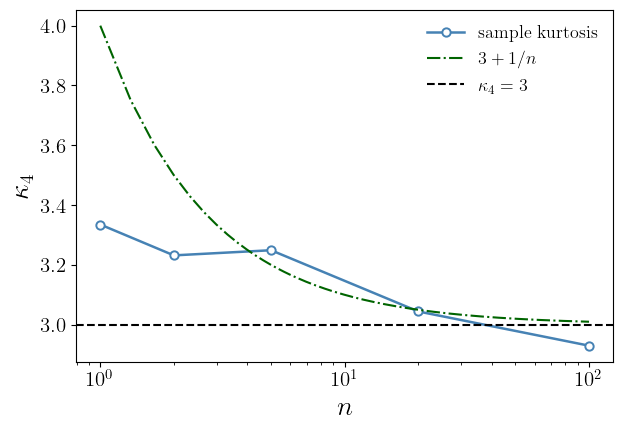

n values:         [1, 2, 5, 20, 100]
Sample kurtosis:  ['3.335', '3.232', '3.249', '3.044', '2.930']


In [ ]:
# --- Part (c): sample kurtosis vs n ---
kurtosis_values = []

for n in n_values:
    # Re-simulate S_n for each n and measure kurtosis.
    draws = rng.poisson(lam=mu_pois, size=(N_samples, n))
    S_n = (draws.sum(axis=1) - n * mu_pois) / np.sqrt(n * mu_pois)
    centred = S_n - S_n.mean()

    # Sample kurtosis kappa_4 = E[(S-mean)^4] / E[(S-mean)^2]^2.
    # A Gaussian has kappa_4 = 3, so convergence toward 3 quantifies CLT behaviour.
    k4 = np.mean(centred**4) / np.mean(centred**2)**2
    kurtosis_values.append(k4)

n_theory = np.linspace(min(n_values), max(n_values), 300)
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.semilogx(
    n_values, kurtosis_values,
    color='steelblue', marker='o', markersize=6,
    markerfacecolor='white', markeredgewidth=1.4,
    lw=1.8, label='sample kurtosis'
)
ax.semilogx(n_theory, 3.0 + 1.0 / n_theory, color='darkgreen', lw=1.5, ls='-.', label=r'$3 + 1/n$')
ax.axhline(3, color='k', linestyle='--', lw=1.5, label=r'$\kappa_4 = 3$')
ax.set_xlabel(r'$n$', fontsize=fontsi2)
ax.set_ylabel(r'$\kappa_4$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi - 2)
fig.subplots_adjust(left=0.14, right=0.98, bottom=0.16, top=0.96)
plt.savefig('./sheet2_output/kurtosis_convergence.pdf')
plt.show()

print('n values:        ', n_values)
print('Sample kurtosis: ', [f'{k:.3f}' for k in kurtosis_values])

# 2.3 Two galaxy samples

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.stats import norm

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

rng = np.random.default_rng(seed=42)

# Synthetic stand-in for the two catalogues used in the sheet.
# A: lower mean and smaller scatter; B: higher mean and larger scatter.
n_a, n_b = 120, 95
sample_a = rng.normal(loc=22500, scale=1800, size=n_a)
sample_b = rng.normal(loc=23200, scale=2600, size=n_b)

In [8]:
# --- Part (a): point estimates ---
def summarise(sample, name):
    n = len(sample)
    mu = sample.mean()
    # ddof=1 gives the unbiased sample variance estimator.
    var = sample.var(ddof=1)
    std = np.sqrt(var)
    print(f'Sample {name}: n={n}, mean={mu:.1f}, var={var:.1f}, std={std:.1f}')
    return n, mu, var, std

n_a, mu_a, var_a, std_a = summarise(sample_a, 'A')
n_b, mu_b, var_b, std_b = summarise(sample_b, 'B')

Sample A: n=120, mean=22391.3, var=1995999.7, std=1412.8
Sample B: n=95, mean=23119.9, var=6750980.0, std=2598.3


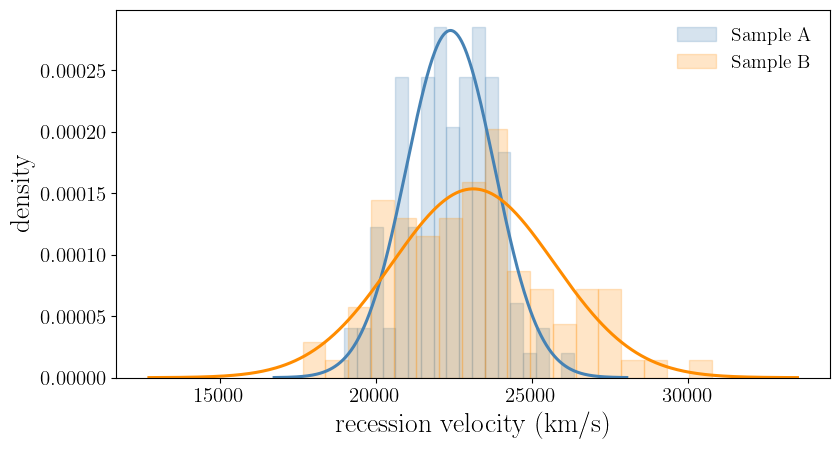

In [ ]:
# --- Part (b): overlapping histograms with Gaussian overlays ---
fig, ax = plt.subplots(figsize=(8.2, 4.6))

for sample, mu, std, label, color in [
    (sample_a, mu_a, std_a, 'Sample A', 'steelblue'),
    (sample_b, mu_b, std_b, 'Sample B', 'darkorange'),
]:
    ax.hist(
        sample,
        bins=18,
        density=True,
        alpha=0.22,
        color=color,
        edgecolor=color,
        linewidth=1.0,
        label=label,
    )
    x = np.linspace(mu - 4.0 * std, mu + 4.0 * std, 400)
    ax.plot(x, norm.pdf(x, mu, std), color=color, lw=2.2)

ax.set_xlabel(r'recession velocity (km/s)', fontsize=fontsi2)
ax.set_ylabel(r'density', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi - 1)
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.16, top=0.96)
plt.savefig('./sheet2_output/galaxy_histograms.pdf')
plt.show()



In [10]:
# --- Part (c): standard errors ---
# Estimate SE(mu_hat) = sigma_hat / sqrt(n) for each catalogue.
se_a = std_a / np.sqrt(n_a)
se_b = std_b / np.sqrt(n_b)
print(f'\nSample A: μ̂ = {mu_a:.1f} ± {se_a:.1f} km/s')
print(f'Sample B: μ̂ = {mu_b:.1f} ± {se_b:.1f} km/s')




Sample A: μ̂ = 22391.3 ± 129.0 km/s
Sample B: μ̂ = 23119.9 ± 266.6 km/s


In [11]:
# --- Part (d): two-sample comparison ---
# Difference in means and propagated SE under independent samples.
delta = mu_a - mu_b
se_delta = np.sqrt(var_a / n_a + var_b / n_b)
z = delta / se_delta

print(f'\nΔ = {delta:.1f} km/s')
print(f'SE(Δ) = {se_delta:.1f} km/s')
print(f'z = Δ / SE(Δ) = {z:.2f}')



Δ = -728.6 km/s
SE(Δ) = 296.1 km/s
z = Δ / SE(Δ) = -2.46


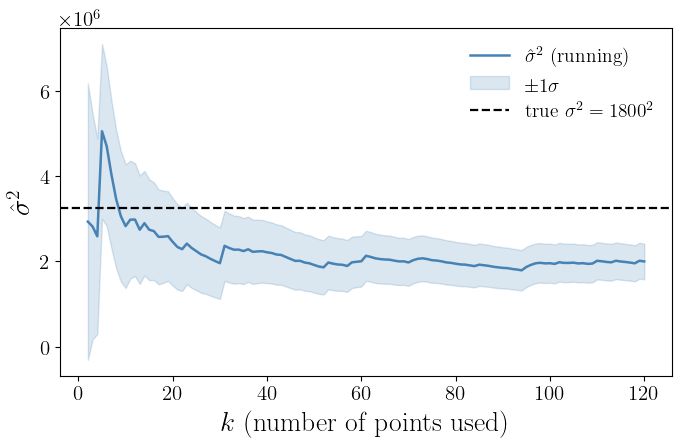

In [ ]:
# --- Part (e): running variance of sample A ---
# Recompute the unbiased variance using only the first k points (k=2..n_a).
k_values = np.arange(2, n_a + 1)
running_var = np.array([np.var(sample_a[:k], ddof=1) for k in k_values])

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(k_values, running_var, color='steelblue', lw=1.8, label=r'$\hat{\sigma}^2$ (running)')

# 1-sigma scatter estimate for var estimator of a Gaussian sample: sqrt(2 sigma^4 / k).
error = (2*1800**4/k_values)**0.5
ax.fill_between(k_values, running_var - error, running_var + error, color='steelblue', alpha=0.2, label=r'$\pm 1 \sigma$')

ax.axhline(1800**2, color='k', linestyle='--', lw=1.6, label=r'true $\sigma^2 = 1800^2$')
ax.set_xlabel(r'$k$ (number of points used)', fontsize=fontsi2)
ax.set_ylabel(r'$\hat{\sigma}^2$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi - 1)
fig.subplots_adjust(left=0.13, right=0.98, bottom=0.17, top=0.96)
plt.savefig('./sheet2_output/running_variance.pdf')
plt.show()

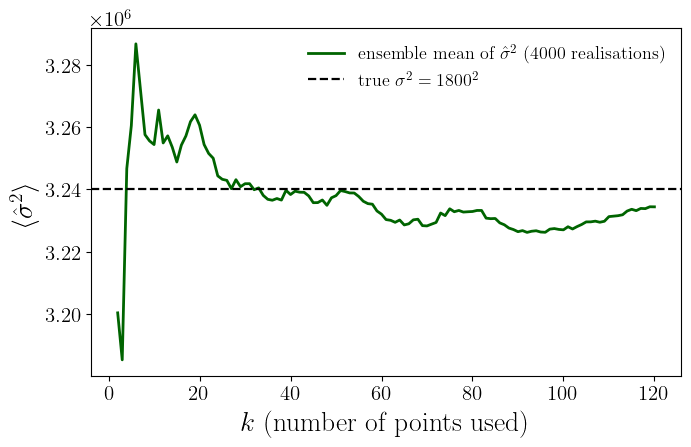

Final ensemble-mean running variance: 3234369.1
True variance: 3240000.0


In [ ]:
# --- Ensemble check: average running variance over many repetitions ---
rng_ensemble = np.random.default_rng(seed=123)
n_realisations = 4000
ensemble_samples = rng_ensemble.normal(loc=22500, scale=1800, size=(n_realisations, n_a))

ensemble_running_var = np.array([
    ensemble_samples[:, :k].var(axis=1, ddof=1).mean()
    for k in k_values
])

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(
    k_values,
    ensemble_running_var,
    color='darkgreen',
    lw=2.0,
    label=rf'ensemble mean of $\hat{{\sigma}}^2$ ({n_realisations} realisations)'
)
ax.axhline(1800**2, color='k', linestyle='--', lw=1.6, label=r'true $\sigma^2 = 1800^2$')
ax.set_xlabel(r'$k$ (number of points used)', fontsize=fontsi2)
ax.set_ylabel(r'$\langle \hat{\sigma}^2 \rangle$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi - 2)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.17, top=0.96)
plt.savefig('./sheet2_output/running_variance_ensemble_mean.pdf')
plt.show()

print(f'Final ensemble-mean running variance: {ensemble_running_var[-1]:.1f}')
print(f'True variance: {1800**2:.1f}')

# 2.4 Questions

1. What is the difference between a population mean $\mu = \mathbb{E}[X]$ and a sample mean $\hat{\mu}$?\
$\mu = \mathbb{E}[X]$ is a fixed property of the distribution, defined by $\int x\,f(x)\,dx$. The sample mean $\hat{\mu} = \frac{1}{n}\sum X_i$ is computed from data and is itself a random variable — it fluctuates between datasets but converges to $\mu$ as $n\to\infty$.


2. The variance, skewness, and kurtosis are the second, third, and fourth central moments of a distribution. Describe in words what each one captures about the shape of a PDF. If you are told that two distributions share the same mean and variance but differ in their third moment, what can you say about how they look different?
- **Variance**: spread/width around the mean
- **Skewness**: asymmetry — which tail is longer
- **Kurtosis**: tail heaviness and peak sharpness
If two distributions share mean and variance but differ in the third moment, they have the same centre and width but one is skewed: the bulk of its mass is shifted to one side.


3. The covariance matrix $\Sigma$ of a random vector is said to be positive semi-definite. What does this property guarantee about the diagonal entries of $\Sigma$?\
Positive semi-definiteness means $v^\top \Sigma\, v \geq 0$ for all $v$. Choosing $v = e_i$ gives $\Sigma_{ii} \geq 0$, guaranteeing all diagonal entries (i.e. individual variances $\sigma_i^2$) are non-negative.


4. Does an unbiased estimator always give you the correct answer? Explain why unbiasedness alone is not sufficient to call an estimator "good", and what additional property should accompany it.\
No. Unbiasedness means $\mathbb{E}[\hat{\theta}] = \theta$ on average, but a single estimate can still be far from the truth if the variance is large. A good estimator also needs low variance and consistency — it must converge to the truth as $n\to\infty$.


5. The Mean Squared Error (MSE) of an estimator decomposes into two terms. Explain in your own words what each term captures and why minimising the MSE alone can be misleading.\
Minimising MSE alone misleads because you can trade bias for variance. A heavily biased estimator with low scatter will converge to the wrong answer no matter how much data you collect.


6. The sample mean $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n X_i$ has variance $\sigma^2/n$. What does this tell you about the practical benefit of collecting more data? Is there a point of diminishing returns, and if so, what is the scaling law that describes it?\
Since $\sigma_{\hat{\mu}} = \sigma/\sqrt{n}$, more data always helps. To halve the uncertainty you must quadruple the sample size. This $1/\sqrt{n}$ scaling is a fundamental limit that no unbiased estimator can beat.


7. Explain intuitively why replacing $\mu$ with $\hat{\mu}$ causes the estimator to systematically underestimate the true variance, and why dividing by $n-1$ instead of $n$ fixes this.\
$\hat{\mu}$ is computed from the same data, and by definition minimises $\sum(X_i - \hat{\mu})^2$. Deviations from $\hat{\mu}$ are therefore always smaller than from the true $\mu$, causing systematic underestimation. 


8. Why the CLT is this result so powerful for practical data analysis? State clearly what assumptions are required and identify one common situation in astrophysics or cosmology where those assumptions may be hard to satisfy.\
The CLT guarantees that sample means become Gaussian regardless of the underlying distribution — justifying Gaussian statistics almost universally. It requires iid samples and finite variance
In cosmology this can fail: different sky regions are not independent due to large-scale correlations in the matter field, and we only have one Universe to observe — making repeated independent experiments impossible.